In [1]:
import pandas as pd
from fitparse import FitFile
from collections import Counter
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt

In [2]:
full_df = pd.read_csv("../final_dfs/full_df.csv")
full_df.head()

,timestamp,stress,body_battery,respiration_rate,heart_rate,activity_type,is_cognitive
0,2026-06-03 00:00:00,NaN,NaN,NaN,NaN,NaN,0
1,2026-06-03 00:01:00,12.0,32.0,13.58,NaN,NaN,0
2,2026-06-03 00:02:00,20.0,32.0,15.36,64.0,NaN,0
3,2026-06-03 00:03:00,NaN,NaN,14.91,74.0,generic,0
4,2026-06-03 00:04:00,22.0,32.0,16.58,64.0,sedentary,0


## 1 Checking Basic Stats

In [4]:
full_df.dtypes

timestamp            object
stress              float64
body_battery        float64
respiration_rate    float64
heart_rate          float64
activity_type        object
is_cognitive          int64
dtype: object

In [5]:
full_df.describe()

,stress,body_battery,respiration_rate,heart_rate,is_cognitive
count,3775.000000,4107.000000,3462.000000,3515.000000,4320.000000
mean,24.243709,56.219382,14.403917,71.916074,0.193750
std,24.014899,21.855631,2.509860,16.747873,0.395281
min,-2.000000,21.000000,0.000000,46.000000,0.000000
25%,7.000000,37.000000,13.000000,59.000000,0.000000
50%,18.000000,54.000000,14.630000,68.000000,0.000000
75%,35.000000,75.000000,16.000000,81.000000,0.000000
max,99.000000,97.000000,22.080000,155.000000,1.000000


## 2 Missing Data and Outliers

In [7]:
# Missing Ratio
round(full_df.isna().sum() / full_df.shape[0], 2)

timestamp           0.00
stress              0.13
body_battery        0.05
respiration_rate    0.20
heart_rate          0.19
activity_type       0.04
is_cognitive        0.00
dtype: float64

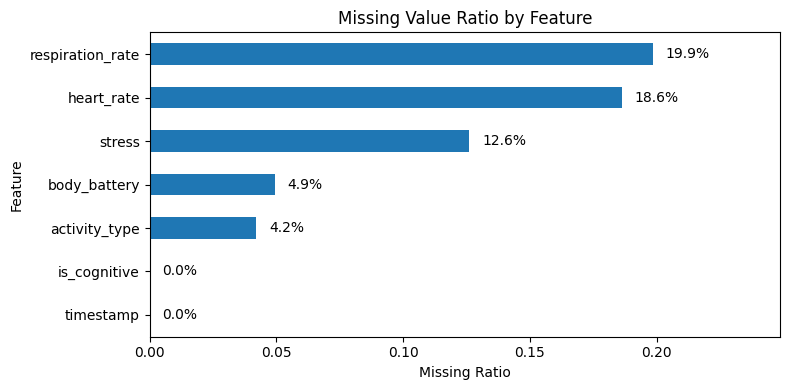

In [8]:
missing_ratio = (
    full_df.isna()
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4))

missing_ratio.plot(
    kind="barh"
)

plt.title("Missing Value Ratio by Feature")
plt.xlabel("Missing Ratio")
plt.ylabel("Feature")

for i, v in enumerate(missing_ratio):
    plt.text(
        v + 0.005,
        i,
        f"{v:.1%}",
        va="center"
    )

plt.xlim(0, missing_ratio.max() + 0.05)
plt.tight_layout()
plt.show()

### Stess

In [10]:
print((full_df["stress"] < 0).sum())
print(round((full_df["stress"] < 0).sum() / full_df.shape[0], 2))

649
0.15


### Respiration

In [12]:
print((full_df["respiration_rate"] == 0).sum())

16


## 3 Distribution Plots

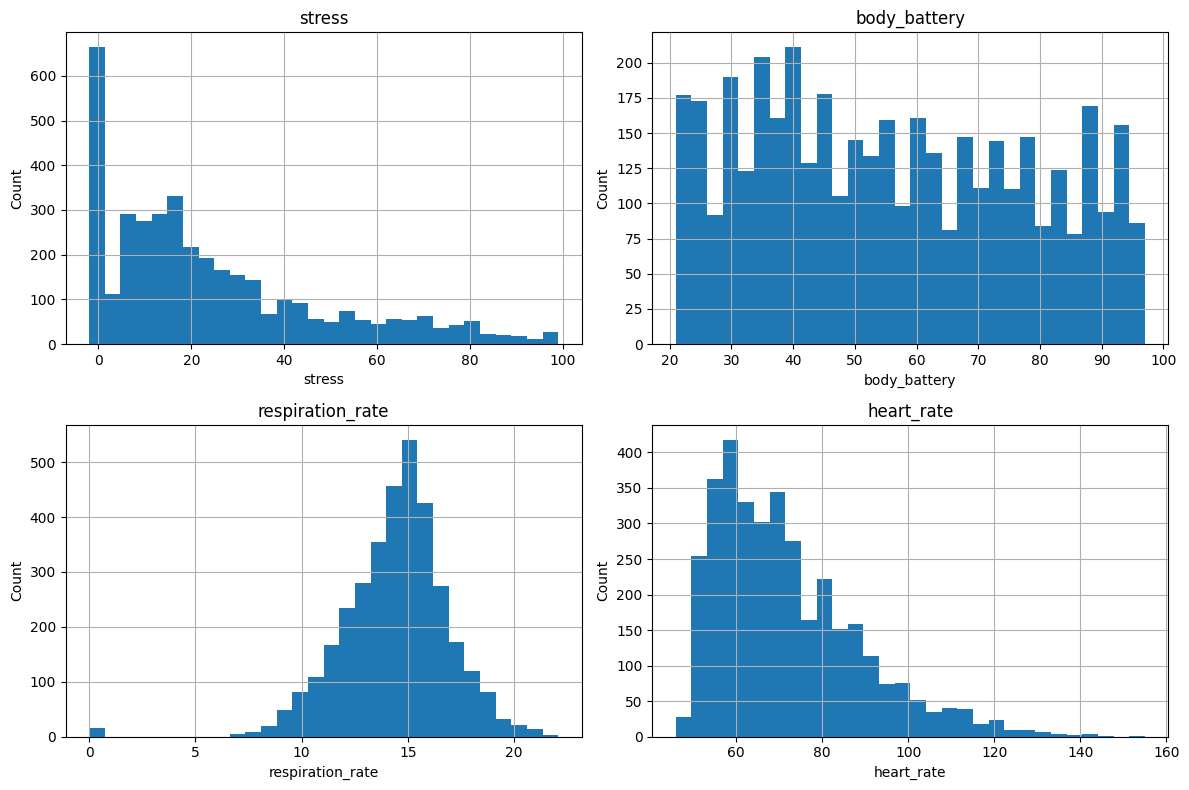

In [14]:
import matplotlib.pyplot as plt

numeric_features = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), numeric_features):
    full_df[col].dropna().hist(
        bins=30,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

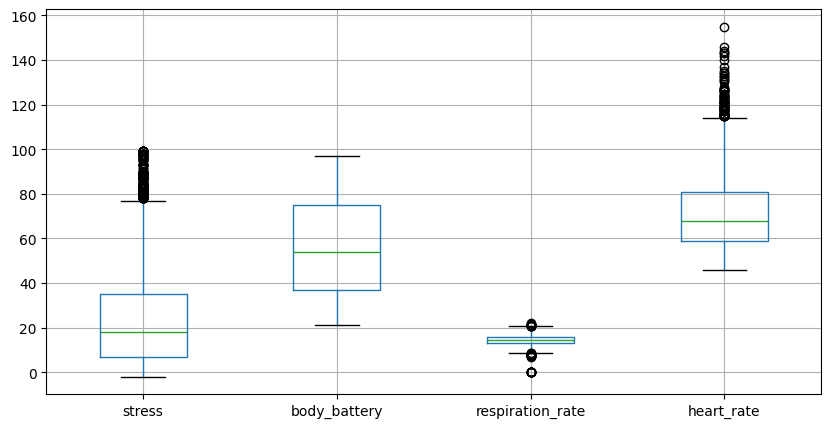

In [15]:
full_df[numeric_features].boxplot(figsize=(10,5))
plt.show()

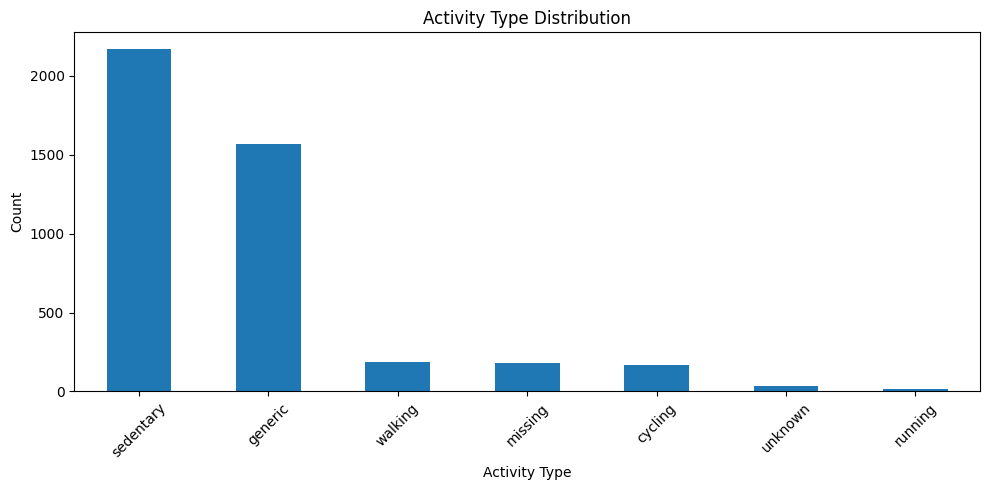

In [16]:
activity_counts = (
    full_df["activity_type"]
    .fillna("missing")
    .value_counts()
)

plt.figure(figsize=(10, 5))
activity_counts.plot(kind="bar")
plt.title("Activity Type Distribution")
plt.ylabel("Count")
plt.xlabel("Activity Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

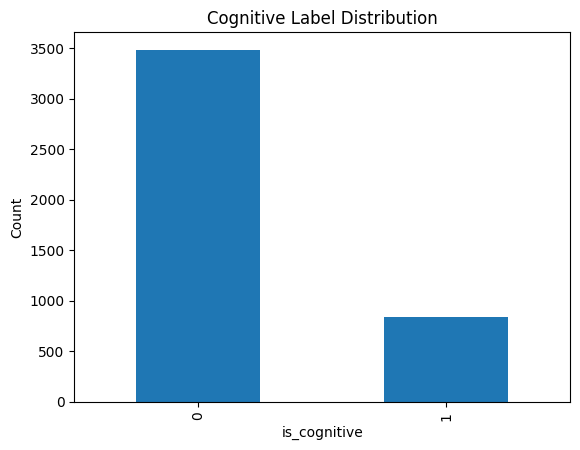

In [17]:
full_df["is_cognitive"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Cognitive Label Distribution")
plt.xlabel("is_cognitive")
plt.ylabel("Count")
plt.show()

## 4 Time Plots

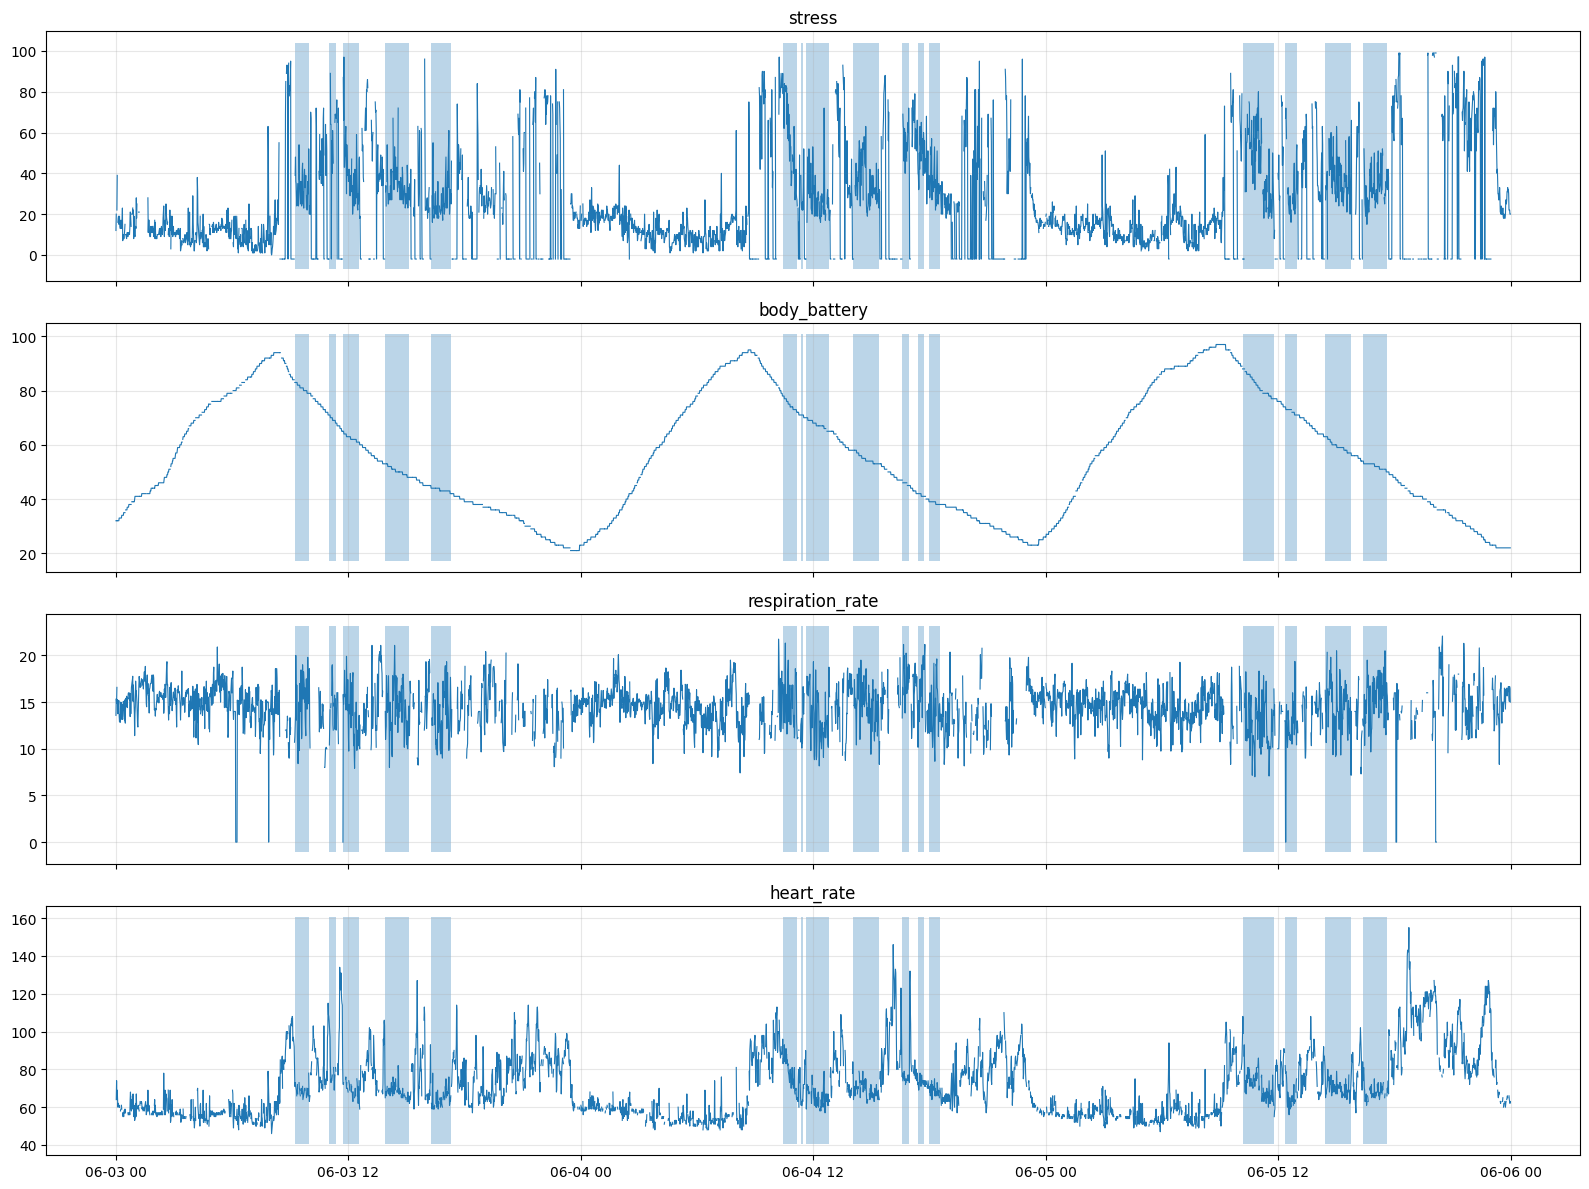

In [19]:
full_df["timestamp"] = pd.to_datetime(full_df["timestamp"])

fig, axes = plt.subplots(
    4, 1,
    figsize=(16, 12),
    sharex=True
)

features = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate"
]

for ax, feature in zip(axes, features):

    ax.plot(
        full_df["timestamp"],
        full_df[feature],
        linewidth=0.8
    )

    # shade cognitive periods
    cognitive = full_df["is_cognitive"] == 1

    ax.fill_between(
        full_df["timestamp"],
        ax.get_ylim()[0],
        ax.get_ylim()[1],
        where=cognitive,
        alpha=0.3
    )

    ax.set_title(feature)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()